# Fine-Tuned CLIP Fashion Product Search System

## Project description

This project develops a multimodal system for an online fashion store. A user describes a product in English, and the system retrieves and displays the most suitable images from the product catalogue. The system is based on a fine-tuned CLIP model that aligns text descriptions and images in a shared vector space.

## Objectives

1. Fine-tune the pretrained CLIP model (`openai/clip-vit-base-patch32`) on a fashion-product dataset to improve the alignment of images and text descriptions in this domain.
2. Implement a search system that returns the most relevant catalogue images for a text query.

## Course metric

A mean diagonal CLIP logit above 30 on validation data after fine-tuning.


In [ ]:
import os
import zipfile
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
import torch
from functools import partial
from torch.utils.data import DataLoader
from transformers import CLIPModel, CLIPProcessor
from tqdm import tqdm
import time
import numpy as np
import random

In [ ]:
drive.mount('/content/drive')

ZIP_PATH = '/content/drive/MyDrive/archive.zip'
DATA_DIR = '/content/clothing_data'

os.makedirs(DATA_DIR, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(DATA_DIR)

In [ ]:
SEED = 42

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

set_seed()
train_generator = torch.Generator().manual_seed(SEED)


## Stage 1: CLIP fine-tuning


In [4]:
CSV_PATH = os.path.join(DATA_DIR, 'data.csv')
IMAGES_DIR = os.path.join(DATA_DIR, 'data')

df = pd.read_csv(CSV_PATH)

print('Table shape:', df.shape)
print('\nColumns:', list(df.columns))
print('\nFirst rows:')
print(df.head())

print('\nMissing values by column:')
print(df.isna().sum())

print('\nExample image files:')
print(os.listdir(IMAGES_DIR)[:10])
print('Total image files:', len(os.listdir(IMAGES_DIR)))

Table shape: (44441, 4)

Columns: ['image', 'description', 'display name', 'category']

First rows:
       image                                        description  \
0   3238.jpg  Round toed, black sports shoes with red accent...   
1  43044.jpg  Style Note Built with the breathability and ze...   
2  54018.jpg  Teal  handbag that has stitch detailing with a...   
3   8141.jpg  Perfectly stylish, this fastrack analog wrist ...   
4  22245.jpg  These id mid-top chukka shoes add a fresh spin...   

                                        display name      category  
0         Puma Men Black 65CC Lo Ducati Sports Shoes  Sports Shoes  
1                      Nike Men Charcoal Grey Shorts        Shorts  
2                           Kiara Women Teal Handbag      Handbags  
3  Fastrack Women Freestyle Sports Analog Steel B...       Watches  
4                          ID Men Brown Casual Shoes  Casual Shoes  

Missing values by column:
image             0
description     281
display name    

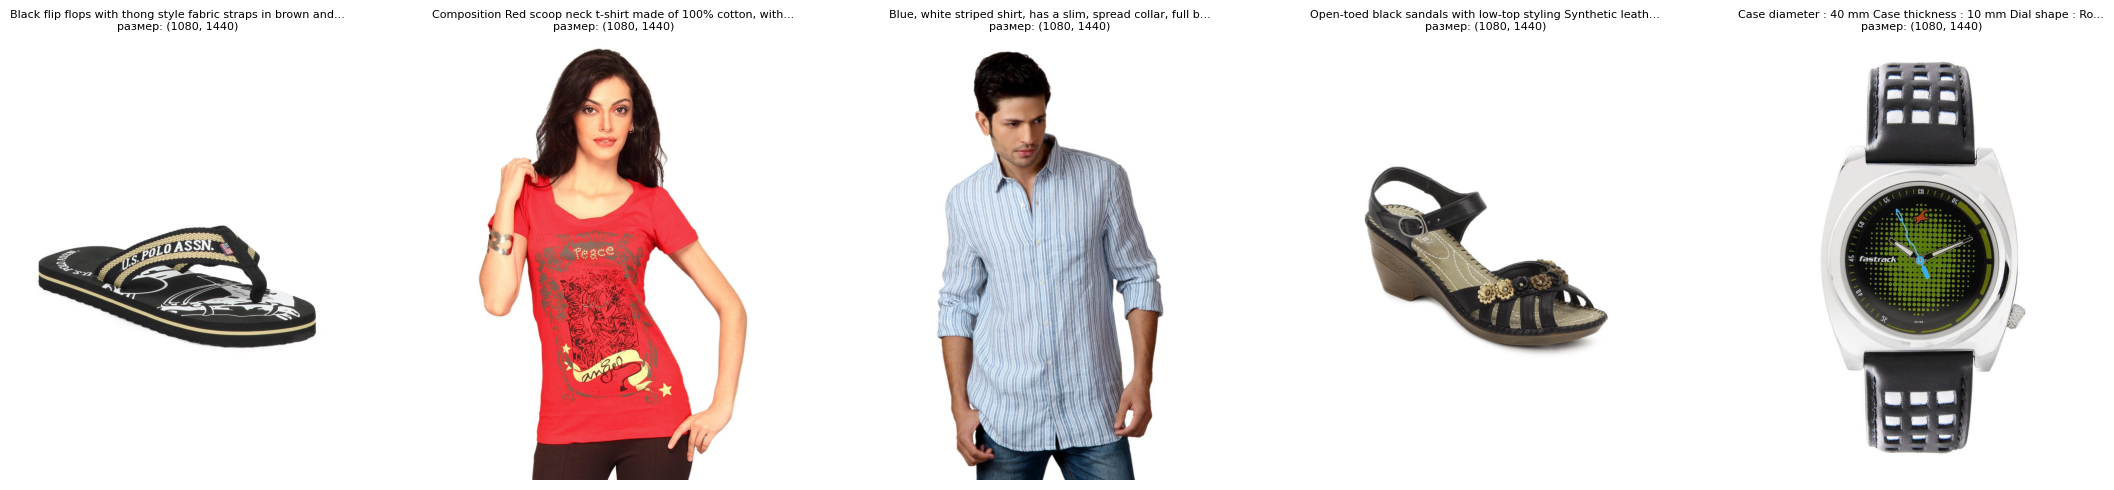

In [5]:
sample = df.dropna(subset=['description']).sample(5, random_state=42)

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, (_, row) in zip(axes, sample.iterrows()):
    img_path = os.path.join(IMAGES_DIR, row['image'])
    image = Image.open(img_path)
    ax.imshow(image)
    ax.axis('off')
    title = f"{row['description'][:60]}...\nsize: {image.size}"
    ax.set_title(title, fontsize=8)

plt.tight_layout()
plt.show()

The dataset contains 44,441 products with images and text descriptions. The number of files in the image directory exactly matches the number of table rows. Missing values occur only in `description` (281 rows, fewer than 1%) and `display name` (7 rows, not used in this project); records without a description will be removed during preprocessing.

All images have the same 1080 × 1440 resolution (portrait orientation, typical of a fashion catalogue). Visual inspection of random examples showed good correspondence between text descriptions and image content.


In [ ]:
# Remove rows without a description
df_clean = df.dropna(subset=['description']).reset_index(drop=True)
print('After removing missing descriptions:', len(df_clean))

# Check duplicates by image–description pair and by each individual field
dup_full = df_clean.duplicated(subset=['image', 'description']).sum()
dup_image = df_clean.duplicated(subset=['image']).sum()
dup_description = df_clean.duplicated(subset=['description']).sum()

print(f'\nComplete duplicates (image + description): {dup_full}')
print(f'Duplicate image filenames: {dup_image}')
print(f'Duplicate descriptions: {dup_description}')

# Remove complete duplicates and duplicate image filenames
df_clean = df_clean.drop_duplicates(subset=['image']).reset_index(drop=True)
print('\nAfter removing duplicate image filenames:', len(df_clean))

# Addressed based on reviewer feedback: this split is used every epoch, so it is validation data
train_df, validation_df = train_test_split(
    df_clean,
    test_size=0.1,
    random_state=SEED,
)
train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)

print('\nTrain records:', len(train_df))
print('Validation records:', len(validation_df))

After removing missing descriptions: 44160

Complete duplicates (image + description): 0
Duplicate image filenames: 0
Duplicate descriptions: 5304

After removing duplicate image filenames: 44160

Train records: 39744
Validation records: 4416


A total of 281 records with a missing description were removed. No complete duplicates or duplicate image filenames were found. There are 5,304 cases in which the same text description is used for different images, likely repeated variants of the same product such as different colours or product photographs. These records were retained because each represents a valid unique image, but such pairs can create semantically similar positives within contrastive-learning batches.


## Stage 1: CLIP fine-tuning


In [ ]:
class ClothingCLIPDataset(Dataset):
    """
    PyTorch dataset for CLIP that loads images and text descriptions.
    """

    def __init__(self, dataframe, images_dir):
        self.df = dataframe.reset_index(drop=True)
        self.images_dir = images_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row['image'])
        image = Image.open(img_path).convert('RGB')
        text = row['description']
        return {'image': image, 'text': text}


def clip_collate_fn(batch, processor):
    images = [item['image'] for item in batch]
    texts = [item['text'] for item in batch]

    inputs = processor(
        text=texts,
        images=images,
        return_tensors='pt',
        padding=True,
        truncation=True,
    )
    return inputs


# Dataset sanity check
train_dataset = ClothingCLIPDataset(train_df, IMAGES_DIR)
validation_dataset = ClothingCLIPDataset(validation_df, IMAGES_DIR)

sample = train_dataset[0]
print('Dataset example:')
print('Text:', sample['text'][:100])
print('Image size:', sample['image'].size)
print('\nTrain records:', len(train_dataset))
print('Validation records:', len(validation_dataset))

Dataset example:
Text: Purple printed tunic made of sheer, woven 100% polyester fabric, has a round-neck, is sleeveless wit
Image size: (1080, 1440)

Train records: 39744
Validation records: 4416


In [ ]:
# CLIP model, processor, and reproducible DataLoaders
MODEL_NAME = 'openai/clip-vit-base-patch32'
device = 'cuda' if torch.cuda.is_available() else 'cpu'

processor = CLIPProcessor.from_pretrained(MODEL_NAME)
model = CLIPModel.from_pretrained(MODEL_NAME).to(device)

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=partial(clip_collate_fn, processor=processor),
    num_workers=2,
    worker_init_fn=seed_worker,
    generator=train_generator,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=partial(clip_collate_fn, processor=processor),
    num_workers=2,
    worker_init_fn=seed_worker,
)

# Batch-structure check
batch = next(iter(train_loader))
for key, value in batch.items():
    print(key, value.shape if torch.is_tensor(value) else type(value))

In [ ]:
# Baseline before fine-tuning
@torch.no_grad()
def mean_diagonal_logit(model, dataloader, device):
    model.eval()
    scores = []
    for batch in tqdm(dataloader, desc='Baseline validation'):
        batch = {key: value.to(device) for key, value in batch.items()}
        outputs = model(**batch)
        scores.extend(torch.diagonal(outputs.logits_per_image).cpu().tolist())
    return float(np.mean(scores))

model.eval()
with torch.no_grad():
    batch = next(iter(validation_loader))
    batch = {key: value.to(device) for key, value in batch.items()}
    outputs = model(**batch)
    diagonal_scores = torch.diagonal(outputs.logits_per_image)

print('Diagonal CLIP logits for the first 10 paired validation examples:')
print(diagonal_scores[:10].cpu().numpy())
print('Mean diagonal CLIP logit for this batch:', diagonal_scores.mean().item())

baseline_validation_score = mean_diagonal_logit(model, validation_loader, device)
print(f'Full validation mean diagonal CLIP logit before fine-tuning: {baseline_validation_score:.2f}')

Diagonal CLIP logits for the first 10 paired validation examples:
[32.02783  27.060667 33.279114 31.366882 26.815691 31.946356 29.587078
 32.583073 34.230206 25.956429]
Mean diagonal CLIP logit for this batch: 30.762828826904297


Validation: 100%|██████████| 69/69 [00:30<00:00,  2.26it/s]

Full validation mean diagonal CLIP logit before fine-tuning: 29.87


## Baseline before fine-tuning

The mean diagonal logit on one validation batch is a lightweight diagnostic. The full validation mean printed above is the appropriate baseline for comparison with the fine-tuned model because it uses all validation records. A CLIP logit is a model-specific similarity diagnostic; it is not Recall@K, mAP, or a probability.


In [ ]:
# One training epoch using CLIP's standard symmetric contrastive loss

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()

    epoch_losses = []
    epoch_clip_scores = []

    for batch in tqdm(dataloader, desc='Training'):
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch, return_loss=True)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        # Batch CLIP diagnostic: mean similarity of each image to its paired text
        with torch.no_grad():
            diagonal_scores = torch.diagonal(outputs.logits_per_image)
            batch_clip_score = diagonal_scores.mean().item()

        epoch_losses.append(loss.item())
        epoch_clip_scores.append(batch_clip_score)

    return epoch_losses, epoch_clip_scores

In [11]:
@torch.no_grad()
def validate(model, dataloader, device):
    return mean_diagonal_logit(model, dataloader, device)

In [ ]:
# Reproducible multi-epoch training with validation tracking and checkpoints
CHECKPOINT_DIR = '/content/drive/MyDrive/clip_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

NUM_EPOCHS = 4
LEARNING_RATE = 5e-6

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

history = {
    'train_loss_per_batch': [],
    'train_clip_score_per_batch': [],
    'epoch_validation_clip_score': [],
}
best_validation_score = float('-inf')
best_epoch = None

for epoch in range(NUM_EPOCHS):
    print(f'\n=== Epoch {epoch + 1}/{NUM_EPOCHS} ===')

    train_losses, train_scores = train_one_epoch(model, train_loader, optimizer, device)
    validation_score = validate(model, validation_loader, device)

    history['train_loss_per_batch'].extend(train_losses)
    history['train_clip_score_per_batch'].extend(train_scores)
    history['epoch_validation_clip_score'].append(validation_score)

    avg_train_loss = float(np.mean(train_losses))
    avg_train_score = float(np.mean(train_scores))

    print(f'Mean train loss: {avg_train_loss:.4f}')
    print(f'Mean train diagonal CLIP logit: {avg_train_score:.2f}')
    print(f'Validation mean diagonal CLIP logit: {validation_score:.2f}')

    epoch_checkpoint_path = os.path.join(CHECKPOINT_DIR, f'clip_epoch_{epoch + 1}.pt')
    torch.save(model.state_dict(), epoch_checkpoint_path)

    if validation_score > best_validation_score:
        best_validation_score = validation_score
        best_epoch = epoch + 1
        best_checkpoint_path = os.path.join(CHECKPOINT_DIR, 'clip_best.pt')
        torch.save(model.state_dict(), best_checkpoint_path)
        print(f'New best validation checkpoint: epoch {best_epoch}')

print(f'\nBest validation checkpoint: epoch {best_epoch} with mean diagonal CLIP logit {best_validation_score:.2f}')


=== Epoch 1/4 ===


Validation: 100%|██████████| 69/69 [00:33<00:00,  2.07it/s]


Mean train loss: 0.5023
Mean train diagonal CLIP logit: 29.74
Validation mean diagonal CLIP logit: 29.67
New best validation checkpoint: epoch 1

=== Epoch 2/4 ===


Validation: 100%|██████████| 69/69 [00:33<00:00,  2.07it/s]


Mean train loss: 0.2830
Mean train diagonal CLIP logit: 30.79
Validation mean diagonal CLIP logit: 30.90
New best validation checkpoint: epoch 2

=== Epoch 3/4 ===


Validation: 100%|██████████| 69/69 [00:35<00:00,  1.93it/s]


Mean train loss: 0.2000
Mean train diagonal CLIP logit: 31.46
Validation mean diagonal CLIP logit: 31.19
New best validation checkpoint: epoch 3

=== Epoch 4/4 ===


Validation: 100%|██████████| 69/69 [00:33<00:00,  2.04it/s]


Mean train loss: 0.1531
Mean train diagonal CLIP logit: 32.01
Validation mean diagonal CLIP logit: 31.34
New best validation checkpoint: epoch 4

Best validation checkpoint: epoch 4 with mean diagonal CLIP logit 31.34


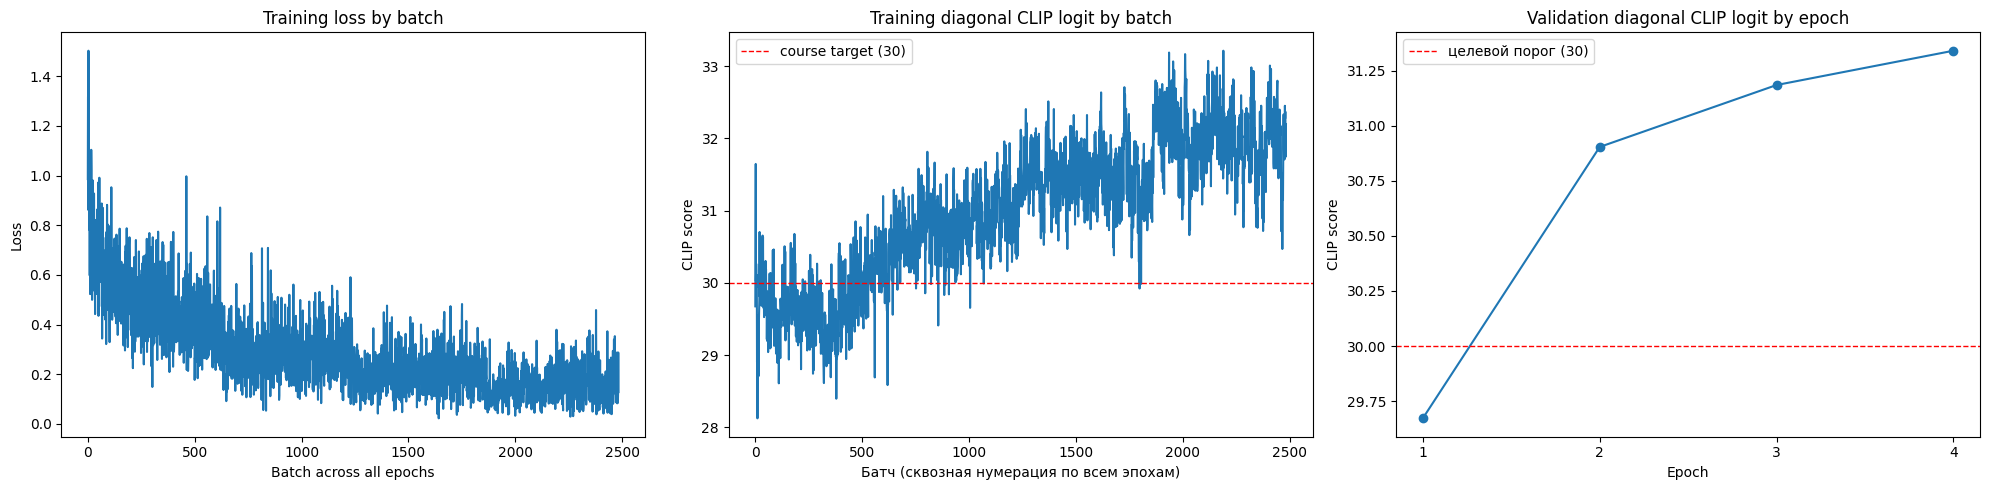

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Loss by batch
axes[0].plot(history['train_loss_per_batch'])
axes[0].set_title('Training loss by batch')
axes[0].set_xlabel('Batch across all epochs')
axes[0].set_ylabel('Loss')

# Training diagonal CLIP logit by batch
axes[1].plot(history['train_clip_score_per_batch'])
axes[1].axhline(30, color='red', linestyle='--', linewidth=1, label='course target (30)')
axes[1].set_title('Training diagonal CLIP logit by batch')
axes[1].set_xlabel('Batch across all epochs')
axes[1].set_ylabel('Diagonal CLIP logit')
axes[1].legend()

# Validation diagonal CLIP logit by epoch
epochs = list(range(1, len(history['epoch_validation_clip_score']) + 1))
axes[2].plot(epochs, history['epoch_validation_clip_score'], marker='o')
axes[2].axhline(30, color='red', linestyle='--', linewidth=1, label='course target (30)')
axes[2].set_title('Validation diagonal CLIP logit by epoch')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Diagonal CLIP logit')
axes[2].set_xticks(epochs)
axes[2].legend()

plt.tight_layout()
plt.show()

## Fine-tuning results

The reproducible run uses a fixed seed (`42`), 39,744 training image–description pairs, and 4,416 validation pairs. The baseline and all epoch values below are **full-validation mean diagonal CLIP logits**, not independent test metrics.

| Stage | Mean training loss | Mean training diagonal logit | Validation diagonal logit |
|---|---:|---:|---:|
| Pretrained CLIP baseline | — | — | 29.87 |
| Epoch 1 | 0.5023 | 29.74 | 29.67 |
| Epoch 2 | 0.2830 | 30.79 | 30.90 |
| Epoch 3 | 0.2000 | 31.46 | 31.19 |
| Epoch 4 | 0.1531 | 32.01 | **31.34** |

The selected checkpoint is `clip_best.pt` from epoch 4. Fine-tuning raised the full validation diagonal logit by **1.47** points, from 29.87 to 31.34, which is a relative increase of 4.92%. The coursework target of 30 was exceeded from epoch 2 onward. Training loss decreased throughout the run, while the observed validation criterion increased at every epoch after epoch 1.

This result supports the claim that the fine-tuned model performs better under the coursework diagonal-logit criterion on this validation split. It is not an independent test result, and it does not by itself quantify an improvement in Recall@K over the original CLIP model.


## Stage 2: Implementing the product search system


In [ ]:
MODEL_NAME = 'openai/clip-vit-base-patch32'
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# The best validation checkpoint from the reproducible training cell
CHECKPOINT_PATH = '/content/drive/MyDrive/clip_checkpoints/clip_best.pt'
EMBEDDINGS_DIR = '/content/drive/MyDrive/clip_search_index'
os.makedirs(EMBEDDINGS_DIR, exist_ok=True)

# A new artifact tag prevents accidental reuse of embeddings from an earlier checkpoint
INDEX_TAG = 'clip_best_seed42'
IMAGE_EMBEDDINGS_PATH = os.path.join(EMBEDDINGS_DIR, f'image_embeddings_{INDEX_TAG}.npy')
IMAGE_IDS_PATH = os.path.join(EMBEDDINGS_DIR, f'image_ids_{INDEX_TAG}.npy')

processor = CLIPProcessor.from_pretrained(MODEL_NAME)
model = CLIPModel.from_pretrained(MODEL_NAME)
state_dict = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()


class ImageOnlyDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, images_dir):
        self.df = dataframe.reset_index(drop=True)
        self.images_dir = images_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row['image'])
        image = Image.open(img_path).convert('RGB')
        return {'image': image, 'image_name': row['image']}


def image_collate_fn(batch, processor):
    images = [item['image'] for item in batch]
    names = [item['image_name'] for item in batch]
    inputs = processor(images=images, return_tensors='pt')
    return inputs, names

full_dataset = ImageOnlyDataset(df_clean, IMAGES_DIR)
full_loader = DataLoader(
    full_dataset,
    batch_size=128,
    shuffle=False,
    collate_fn=partial(image_collate_fn, processor=processor),
    num_workers=2,
)

if os.path.exists(IMAGE_EMBEDDINGS_PATH) and os.path.exists(IMAGE_IDS_PATH):
    image_embeddings = np.load(IMAGE_EMBEDDINGS_PATH)
    image_ids = np.load(IMAGE_IDS_PATH, allow_pickle=True)
else:
    all_embeddings = []
    all_names = []

    start = time.time()
    with torch.no_grad():
        for pixel_inputs, names in tqdm(full_loader, desc='Encoding images'):
            pixel_inputs = {k: v.to(device) for k, v in pixel_inputs.items()}

            # Directly use the vision_model part of CLIPModel to get the output object
            # then extract the pooler_output which is the tensor representation
            vision_output = model.vision_model(pixel_values=pixel_inputs['pixel_values'], return_dict=True)
            image_features = model.visual_projection(vision_output.pooler_output)

            # Normalize the image features
            image_features = image_features / image_features.norm(p=2, dim=-1, keepdim=True)
            all_embeddings.append(image_features.cpu().numpy())
            all_names.extend(names)
    embedding_time = time.time() - start

    image_embeddings = np.concatenate(all_embeddings, axis=0)
    image_ids = np.array(all_names)

    np.save(IMAGE_EMBEDDINGS_PATH, image_embeddings)
    np.save(IMAGE_IDS_PATH, image_ids)
    print(f'Embeddings computed in {embedding_time:.1f} seconds for {len(image_ids)} images')

print('\nEmbedding matrix shape:', image_embeddings.shape)
print('Number of image IDs:', len(image_ids))

In [ ]:
# Addressed based on reviewer feedback: support both documented CLIP return contracts
def get_projected_text_features(model, text_inputs):
    features = model.get_text_features(**text_inputs)
    if hasattr(features, 'pooler_output') and isinstance(features.pooler_output, torch.Tensor):
        return features.pooler_output
    if isinstance(features, torch.Tensor):
        return features
    raise TypeError(f'Unexpected get_text_features output type: {type(features)}')

print('Model projection dimension:', model.config.projection_dim)
print('Image embedding dimension:', image_embeddings.shape[1])

sample_text_inputs = processor(
    text=['a red dress'],
    return_tensors='pt',
    padding=True,
    truncation=True,
).to(device)
with torch.no_grad():
    sample_text_features = get_projected_text_features(model, sample_text_inputs)

print('Projected text embedding dimension:', sample_text_features.shape[1])

Model projection dimension: 512
Image embedding dimension: 512
Projected text embedding dimension: 512


In [ ]:
# Text-to-image product search
def search_products(query, model, processor, image_embeddings, image_ids, images_dir, top_k=5, device=None):
    """Return the top-k catalogue images for one non-empty English text query."""
    if not isinstance(query, str) or not query.strip():
        raise ValueError('query must be a non-empty string')
    if not 1 <= top_k <= len(image_ids):
        raise ValueError(f'top_k must be between 1 and {len(image_ids)}')
    if device is None:
        device = next(model.parameters()).device

    model.eval()
    # Addressed based on reviewer feedback: truncation protects CLIP's text context limit
    text_inputs = processor(
        text=[query],
        return_tensors='pt',
        padding=True,
        truncation=True,
    ).to(device)

    with torch.no_grad():
        text_features = get_projected_text_features(model, text_inputs)
        text_features = torch.nn.functional.normalize(text_features, p=2, dim=-1)

    text_embedding = text_features.cpu().numpy()[0]
    scores = image_embeddings @ text_embedding
    top_indices = np.argsort(-scores)[:top_k]

    results = []
    for idx in top_indices:
        results.append({
            'image_name': str(image_ids[idx]),
            'score': float(scores[idx]),
            'image_path': os.path.join(images_dir, str(image_ids[idx])),
        })
    return results

# Quick qualitative check
test_results = search_products('red skirt', model, processor, image_embeddings, image_ids, IMAGES_DIR, top_k=5, device=device)
for result in test_results:
    print(f"{result['image_name']} — score: {result['score']:.4f}")

5005.jpg — score: 0.3769
25931.jpg — score: 0.3610
13304.jpg — score: 0.3585
13305.jpg — score: 0.3585
44922.jpg — score: 0.3548


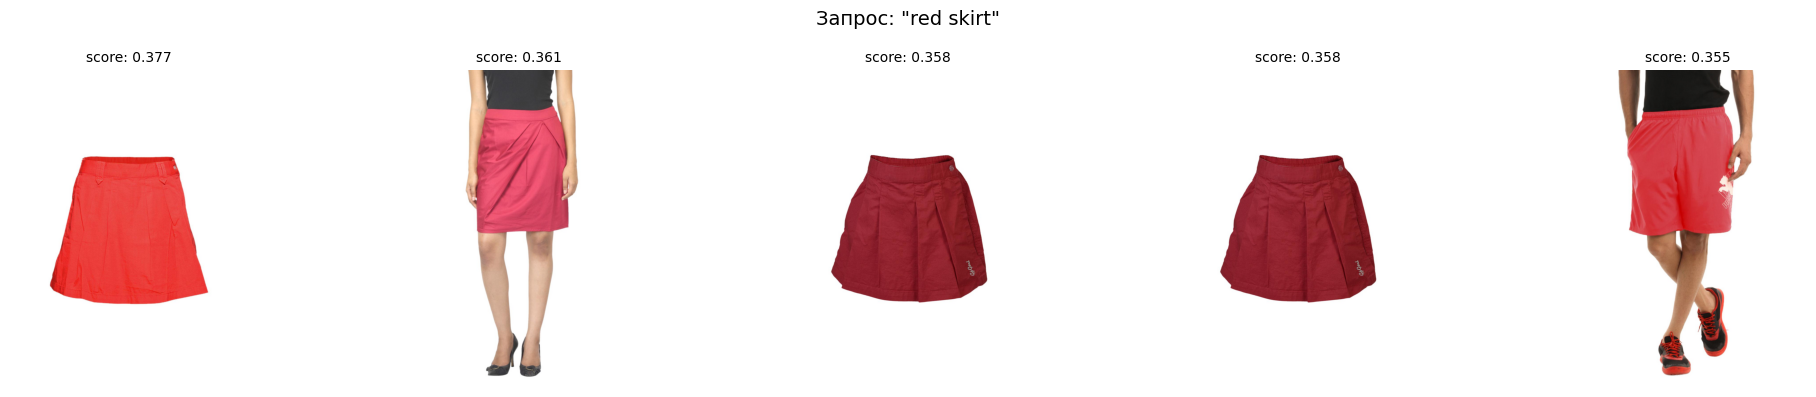

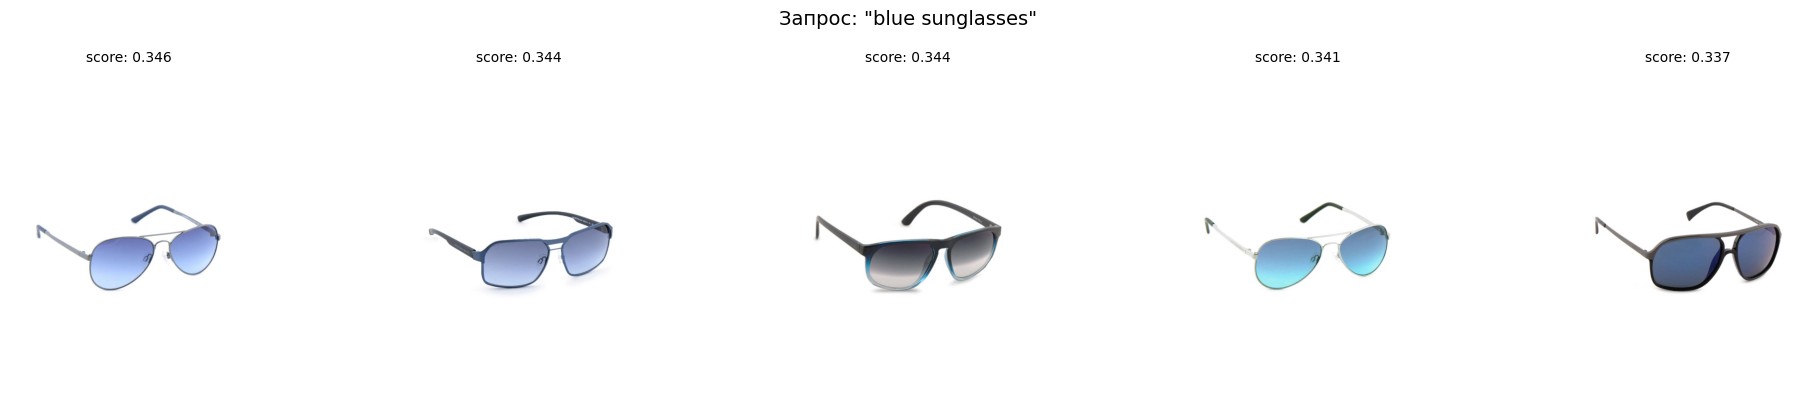

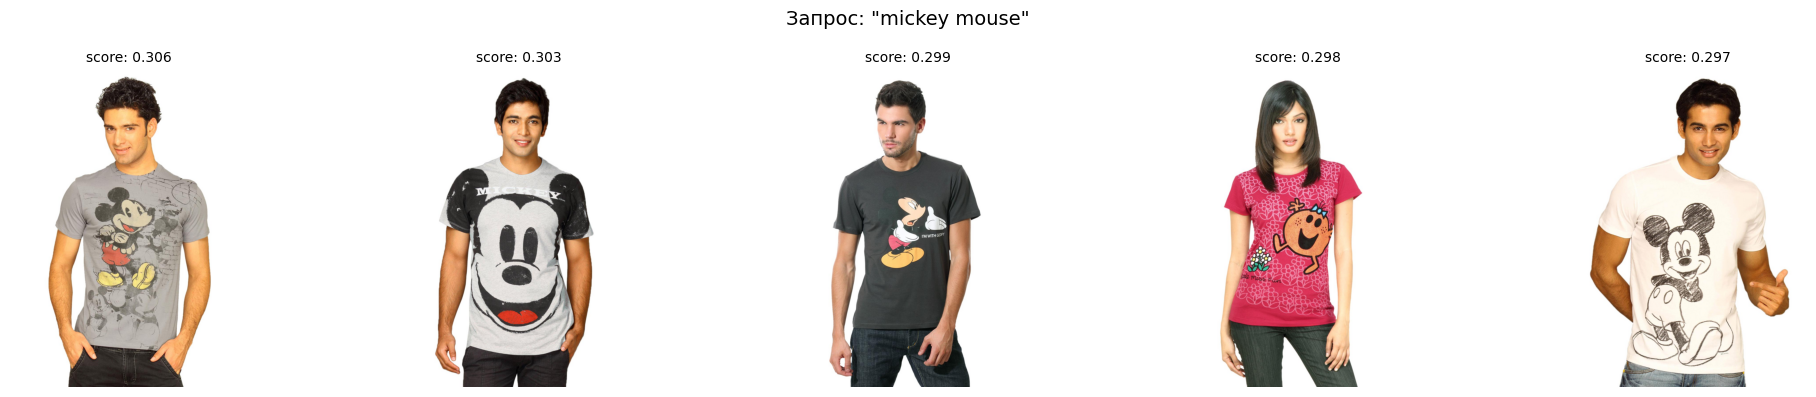

In [17]:
def visualize_search_results(query, results):
    fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4))
    fig.suptitle(f'Query: "{query}"', fontsize=14)

    if len(results) == 1:
        axes = [axes]

    for ax, r in zip(axes, results):
        image = Image.open(r['image_path'])
        ax.imshow(image)
        ax.axis('off')
        ax.set_title(f"score: {r['score']:.3f}", fontsize=10)

    plt.tight_layout()
    plt.show()


test_queries = ['red skirt', 'blue sunglasses', 'mickey mouse']

for query in test_queries:
    results = search_products(query, model, processor, image_embeddings, image_ids, IMAGES_DIR, top_k=5, device=device)
    visualize_search_results(query, results)

## Qualitative search check

The current run returns visually relevant product groups for the three exploratory English queries. For `red skirt`, all five retrieved items are red, burgundy, or pink skirt-like garments, with similarity scores from 0.355 to 0.377. For `blue sunglasses`, all five items are sunglasses and several have visibly blue lenses or frames. For `mickey mouse`, four returned garments visibly feature Mickey Mouse; one remaining result has a different cartoon motif. The examples therefore support meaningful semantic retrieval, while also showing that qualitative inspection is not a substitute for a formal benchmark.

Image embeddings for all 44,160 catalogue images are encoded once and cached in Google Drive. A new query requires only text encoding and a dot product against the cached embedding matrix.



In [18]:
@torch.no_grad()
def evaluate_text_to_image_retrieval(
    evaluation_df,
    model,
    processor,
    image_embeddings,
    image_ids,
    device,
    batch_size=64,
    ks=(1, 5, 10),
):
    """Evaluate strict image-level Recall@K and MRR on validation descriptions."""
    max_k = max(ks)
    if max_k > len(image_ids):
        raise ValueError('The gallery is smaller than max(ks).')

    image_to_position = {str(image_id): position for position, image_id in enumerate(image_ids)}
    gallery = torch.from_numpy(image_embeddings).to(device=device, dtype=torch.float32)
    recalls = {k: [] for k in ks}
    reciprocal_ranks = []

    for start_index in tqdm(range(0, len(evaluation_df), batch_size), desc='Retrieval evaluation'):
        batch_frame = evaluation_df.iloc[start_index:start_index + batch_size]
        text_inputs = processor(
            text=batch_frame['description'].tolist(),
            return_tensors='pt',
            padding=True,
            truncation=True,
        ).to(device)
        text_features = get_projected_text_features(model, text_inputs)
        text_features = torch.nn.functional.normalize(text_features, p=2, dim=-1)
        scores = text_features @ gallery.T

        true_positions = torch.tensor(
            [image_to_position[str(image_name)] for image_name in batch_frame['image']],
            device=device,
        )
        top_positions = torch.topk(scores, k=max_k, dim=1).indices
        target_scores = scores[torch.arange(len(batch_frame), device=device), true_positions]
        ranks = (scores > target_scores.unsqueeze(1)).sum(dim=1) + 1

        for k in ks:
            recalls[k].extend((top_positions[:, :k] == true_positions.unsqueeze(1)).any(dim=1).cpu().tolist())
        reciprocal_ranks.extend((1.0 / ranks.float()).cpu().tolist())

    metrics = {f'Recall@{k}': float(np.mean(values)) for k, values in recalls.items()}
    metrics['MRR'] = float(np.mean(reciprocal_ranks))
    return metrics

retrieval_metrics = evaluate_text_to_image_retrieval(
    validation_df,
    model,
    processor,
    image_embeddings,
    image_ids,
    device,
)

print('Strict image-level retrieval metrics on validation descriptions:')
for metric_name, metric_value in retrieval_metrics.items():
    print(f'{metric_name}: {metric_value:.4f}')


Retrieval evaluation: 100%|██████████| 69/69 [00:03<00:00, 22.78it/s]

Strict image-level retrieval metrics on validation descriptions:
Recall@1: 0.0876
Recall@5: 0.2620
Recall@10: 0.3698
MRR: 0.1809


### Retrieval results and interpretation

The strict image-level retrieval evaluation used all 4,416 validation descriptions as queries against the complete 44,160-image catalogue. The paired image filename is treated as the sole relevant item for each query.

| Metric | Result |
|---|---:|
| Recall@1 | 0.0876 |
| Recall@5 | 0.2620 |
| Recall@10 | 0.3698 |
| Mean Reciprocal Rank (MRR) | 0.1809 |

In practical terms, the exact paired image is ranked first for 8.76% of validation descriptions, appears within the first five results for 26.20%, and appears within the first ten results for 36.98%. MRR is 0.1809, which gives greater credit when the exact paired image appears near the top of the ranking.

These are direct retrieval metrics, unlike the diagonal CLIP logit used as the coursework fine-tuning criterion. They quantify the final fine-tuned model only: a comparable Recall@K/MRR baseline for the original pretrained CLIP model has not been computed, so the notebook must not claim an absolute retrieval-metric gain over the base model.

The catalogue contains 5,304 repeated descriptions. The strict metric counts only one exact image filename as relevant even when another image has the same description, so it may underestimate semantic relevance. Conversely, the random image-level train/validation split may place identical descriptions in both sets, which can make validation results optimistic for entirely unseen descriptions.



### Remaining methodological limitation

This coursework version uses a reproducible random 90/10 image-level split. It is sufficient for the stated validation analysis, but it is not a fully clean estimate of generalisation to unseen descriptions because repeated descriptions can cross the train/validation boundary.

A stricter future experiment would use a group-aware train/validation/test split with `description` as the grouping variable, select the checkpoint on validation data, and evaluate the final model once on an untouched test set. That would require a new training run and is not required to interpret the current reproducible validation results.

